# Demand Forecasting
## Fitness Class Booking Forecast Analysis

In [1]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# =========================================================
# LOAD CLEANED DATASET
# =========================================================

df = pd.read_csv('/content/cleaned_preprocessed_dataset_Tejaswini Yeluduti.csv')

print("Dataset Loaded Successfully")

display(df.head())

Dataset Loaded Successfully


,activity_site_id,activity_description,booking_end_datetime,booking_start_time,max_bookees,number_booked,price_inr,year,month,day,day_name
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,14:45:00,-0.475775,12,-1.709436,2018,4,8,Sunday
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,14:45:00,-0.475775,15,-1.709436,2018,4,15,Sunday
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,14:45:00,-0.475775,14,-1.709436,2018,4,22,Sunday
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,14:45:00,-0.475775,9,-1.709436,2018,4,29,Sunday
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,14:45:00,-0.475775,7,-1.709436,2018,5,6,Sunday


In [3]:
# =========================================================
# CONVERT DATETIME COLUMN
# =========================================================

df['booking_end_datetime'] = pd.to_datetime(
    df['booking_end_datetime']
)

print(df.dtypes)

activity_site_id                object
activity_description            object
booking_end_datetime    datetime64[ns]
booking_start_time              object
max_bookees                    float64
number_booked                    int64
price_inr                      float64
year                             int64
month                            int64
day                              int64
day_name                        object
dtype: object


In [4]:
# =========================================================
# CREATE TIME SERIES DATA
# =========================================================

time_series = (
    df.groupby('booking_end_datetime')['number_booked']
    .sum()
)

time_series = time_series.asfreq('D')

time_series = time_series.fillna(0)

print(time_series.head())

booking_end_datetime
2018-04-01    223
2018-04-02    296
2018-04-03    973
2018-04-04    905
2018-04-05    695
Freq: D, Name: number_booked, dtype: int64


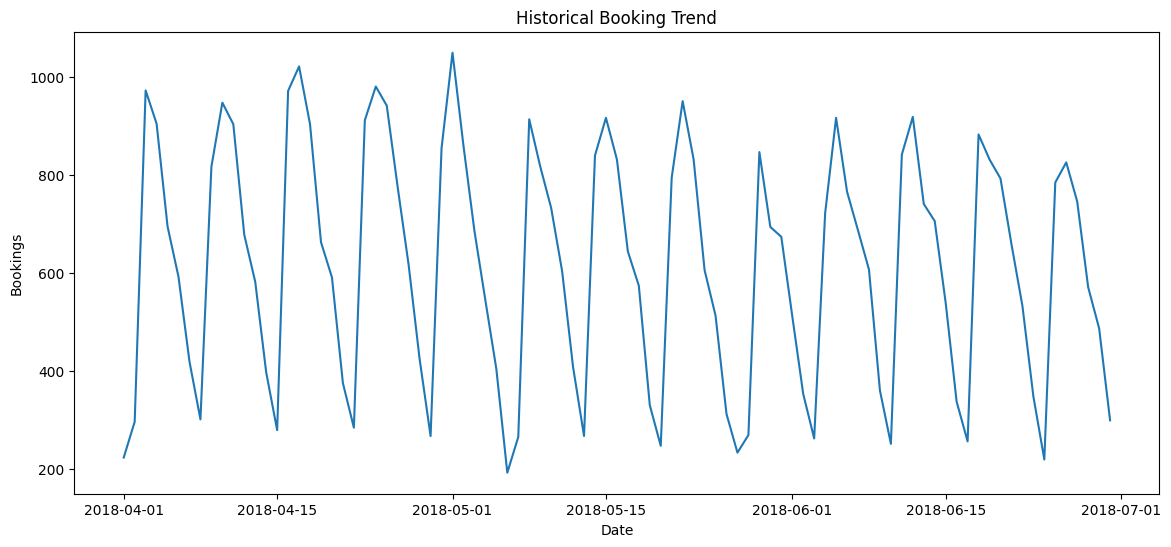

In [5]:
# =========================================================
# HISTORICAL BOOKING TREND
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(time_series)

plt.title('Historical Booking Trend')

plt.xlabel('Date')
plt.ylabel('Bookings')

plt.show()

In [6]:
time_series = pd.to_numeric(
    time_series,
    errors='coerce'
)

time_series = time_series.dropna()
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

train_size = int(len(time_series) * 0.8)

train = time_series[:train_size]

test = time_series[train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 72
Test Size: 19


In [7]:
# =========================================================
# BUILD ARIMA MODEL
# =========================================================

model = ARIMA(
    train,
    order=(1,1,1)
)

model_fit = model.fit()

print("ARIMA Model Training Completed")

ARIMA Model Training Completed


In [8]:
# =========================================================
# GENERATE FORECASTS
# =========================================================

forecast = model_fit.forecast(
    steps=len(test)
)

print(forecast.head())

2018-06-12    721.197759
2018-06-13    665.709644
2018-06-14    640.222278
2018-06-15    628.515161
2018-06-16    623.137729
Freq: D, Name: predicted_mean, dtype: float64


In [9]:
# =========================================================
# MODEL EVALUATION
# =========================================================

mae = mean_absolute_error(
    test,
    forecast
)

mse = mean_squared_error(
    test,
    forecast
)

print("Mean Absolute Error:", round(mae, 2))

print("Mean Squared Error:", round(mse, 2))

Mean Absolute Error: 185.58
Mean Squared Error: 45664.41


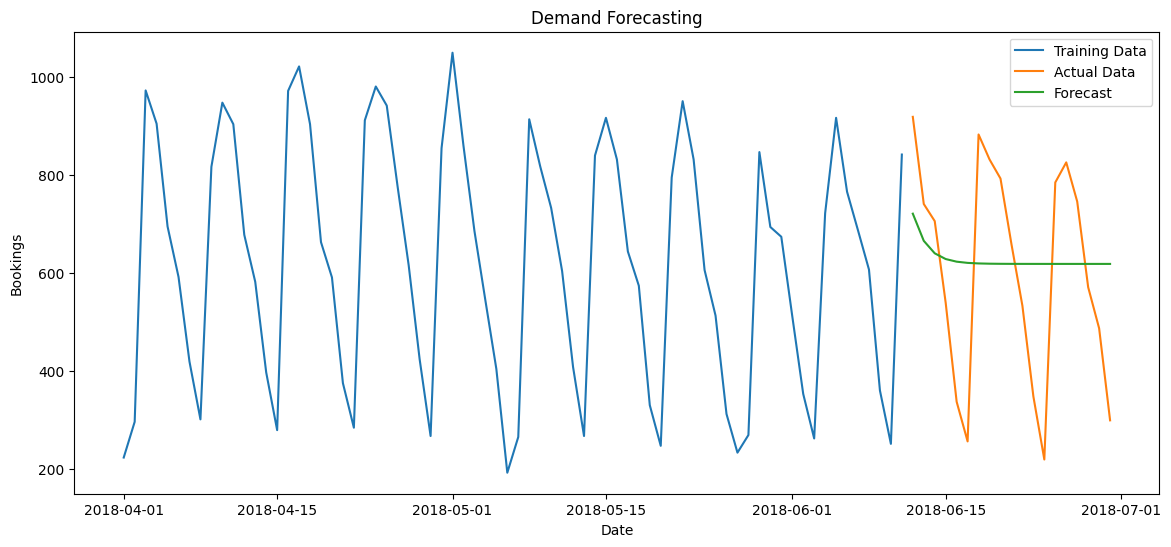

In [10]:
# =========================================================
# FORECAST VISUALIZATION
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train,
    label='Training Data'
)

plt.plot(
    test.index,
    test,
    label='Actual Data'
)

plt.plot(
    test.index,
    forecast,
    label='Forecast'
)

plt.title('Demand Forecasting')

plt.xlabel('Date')
plt.ylabel('Bookings')

plt.legend()

plt.show()

In [11]:
# =========================================================
# FUTURE FORECASTING
# =========================================================

future_forecast = model_fit.forecast(
    steps=14
)

print("Next 14 Days Forecast")

print(future_forecast)

Next 14 Days Forecast
2018-06-12    721.197759
2018-06-13    665.709644
2018-06-14    640.222278
2018-06-15    628.515161
2018-06-16    623.137729
2018-06-17    620.667712
2018-06-18    619.533159
2018-06-19    619.012025
2018-06-20    618.772652
2018-06-21    618.662701
2018-06-22    618.612197
2018-06-23    618.588999
2018-06-24    618.578343
2018-06-25    618.573449
Freq: D, Name: predicted_mean, dtype: float64


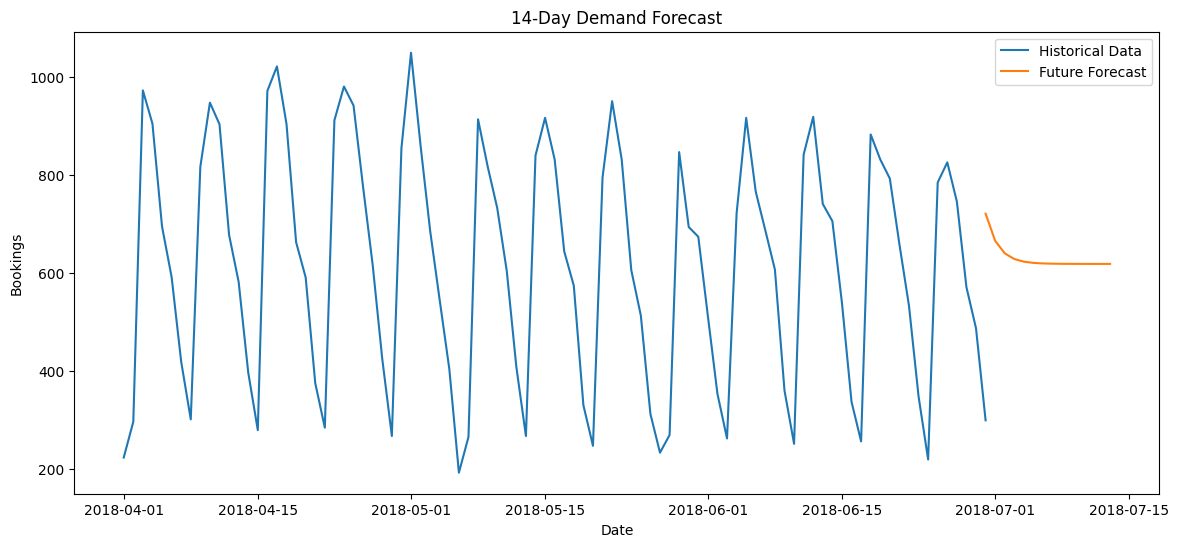

In [12]:
# =========================================================
# FUTURE FORECAST PLOT
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    time_series.index,
    time_series,
    label='Historical Data'
)

future_dates = pd.date_range(
    start=time_series.index[-1],
    periods=14,
    freq='D'
)

plt.plot(
    future_dates,
    future_forecast,
    label='Future Forecast'
)

plt.title('14-Day Demand Forecast')

plt.xlabel('Date')
plt.ylabel('Bookings')

plt.legend()

plt.show()

# Business Insights

- Forecasting helps estimate future booking demand.
- High-demand periods can be identified proactively.
- Forecast results support staffing and scheduling decisions.
- Demand forecasting supports dynamic pricing optimization.
- Future demand spikes may justify premium pricing.

# Conclusion

The ARIMA forecasting model successfully predicted future booking demand trends.

The forecasting analysis provides:
- future demand visibility
- operational planning support
- revenue optimization opportunities
- dynamic pricing insights

These forecasts will support the next stage:
Dynamic Pricing Algorithm Development.